In [1]:
import utils
import os

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 150)

In [2]:
# Preparation
plot_range = [0, 6]
dataset = 'TUS' # TUS, joystick, speakup, africa
split_dataset = False

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [39, 48, 49, 52, 53, 54, 55, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/190526/raw'
    unique_subject_ids = [2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/{dataset}/behavioural/accuracy'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset, remove_reversals=False) # Remove reversals since those don't tell us anything about their performance. Only useful for RT analyses

## Translate objectively_correct and response to percentages and boolean values

In [29]:
# Multiply some variables by 100 to show percentage correct etc
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'] * 100
mapping = {'approach': 1, 'avoid': 0}
combined_results_dataframe['response_boolean'] = combined_results_dataframe['response'].map(mapping)
combined_results_dataframe['response_boolean'] = combined_results_dataframe['response_boolean'].astype('Int64')

combined_results_dataframe_shortened = combined_results_dataframe[combined_results_dataframe['trials_since_reversal_combined_learning']<=10]

## Progress plot

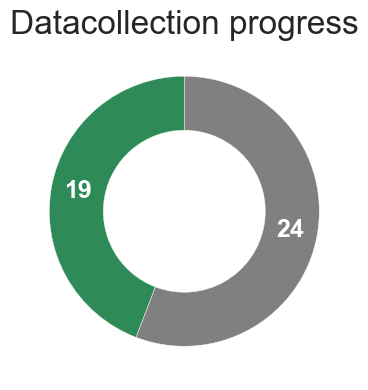

In [5]:
if dataset == 'TUS':
    completed_subjects = 19

    target = 43
    values = [completed_subjects, (target-completed_subjects)]
    colors = ['#2E8B57', 'gray']

    fig, ax = plt.subplots(figsize=(4, 4))
    wedges, texts, autotexts = ax.pie(
        values,
        colors=colors,
        autopct=lambda p: f'{p * sum(values) / 100:.0f}',
        pctdistance=0.8,
        startangle=90,
        wedgeprops=dict(width=0.4, edgecolor='white')  # width < 1 makes it a ring
    )

    plt.setp(autotexts, fontsize=18, fontweight='bold', color='white')

    ax.set_title('Datacollection progress', fontsize=24)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'datacollection_progress.pdf'))

# Sanity checks

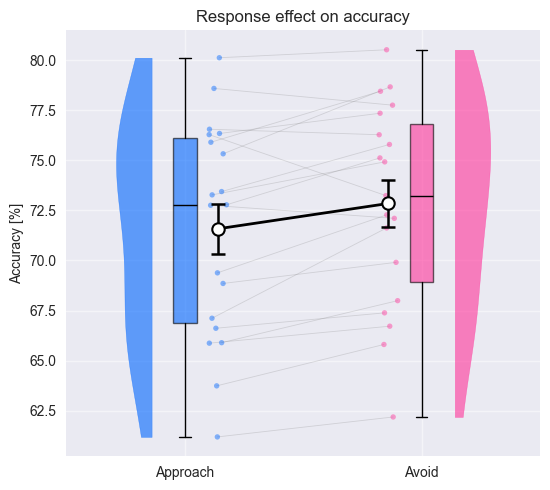

In [31]:
# Check for a response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='response',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['approach', 'avoid'],
    labels=['Approach', 'Avoid'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='Response effect on accuracy'
);

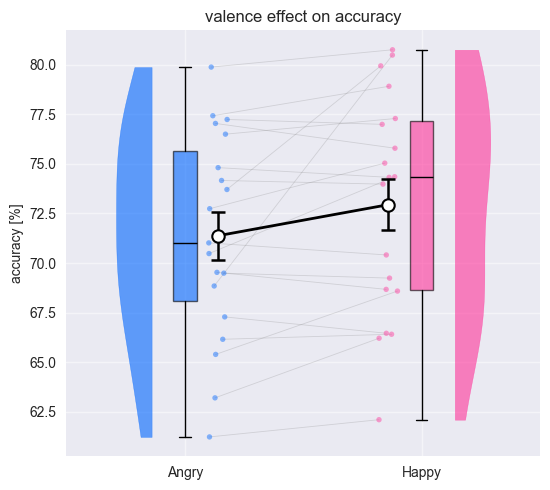

In [32]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='valence',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry', 'happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='valence effect on accuracy'
);

# Average performance over time

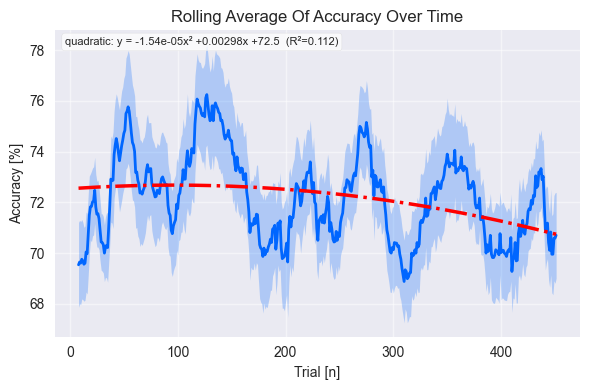

In [33]:
combined_results_dataframe['objectively_correct_rolling_average'] = combined_results_dataframe['objectively_correct_boolean'].rolling(window=40).mean()

utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe,
    x_col='trial', y_col='objectively_correct_rolling_average',
    xlabel_name='trial [n]', ylabel_name='accuracy [%]',
    subject_col='subject_id',
    output_dir=output_dir,
    legend_outside=True,
    trend=['quadratic'], show_trend_stats=True, trend_colour='red',
    plot_name='rolling average of accuracy over time'
);

# Actual analysis

## Congruency

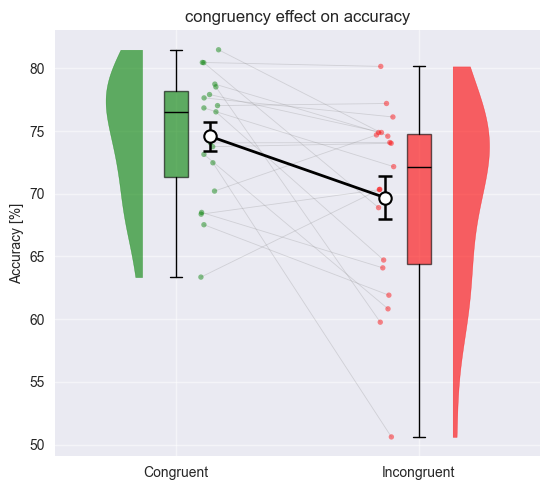

In [34]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    labels=['Congruent', 'Incongruent'],
    flip=['left','right'],
    colours=['green','red'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='congruency effect on accuracy'
);

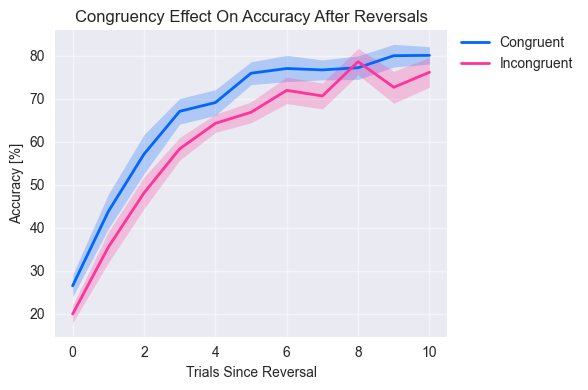

In [35]:
utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe_shortened,
    x_col='trials_since_reversal_combined_learning', y_col='objectively_correct_boolean',
    xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
    subject_col='subject_id', condition_col='congruency',
    output_dir=output_dir,
    legend_outside=True,
    plot_name='congruency effect on accuracy after reversals'
);

In [36]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['congruency', 'stimulation_condition'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{congruency}_{condition}' for congruency, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['congruent_uwd','incongruent_uwd','congruent_control','incongruent_control'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='uwd effect on congruency effect on accuracy'
    );

## Volatility

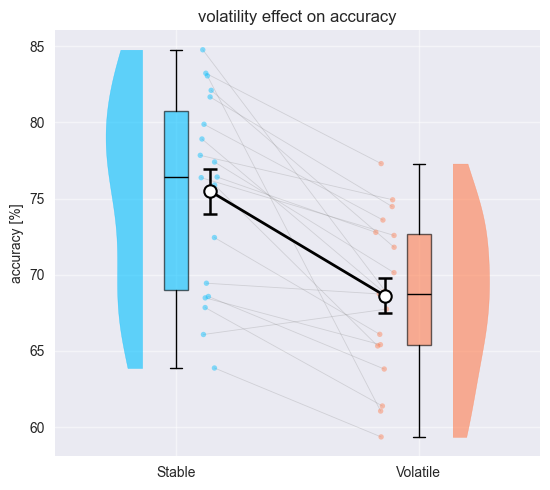

In [37]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        labels=['Stable','Volatile'],
        flip=['left','right'],
        colours=['deepskyblue','coral'],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='volatility effect on accuracy'
    );

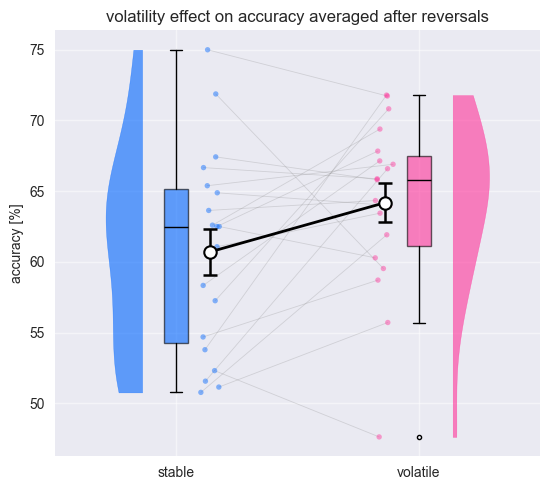

In [38]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_shortened
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='volatility effect on accuracy averaged after reversals'
    );

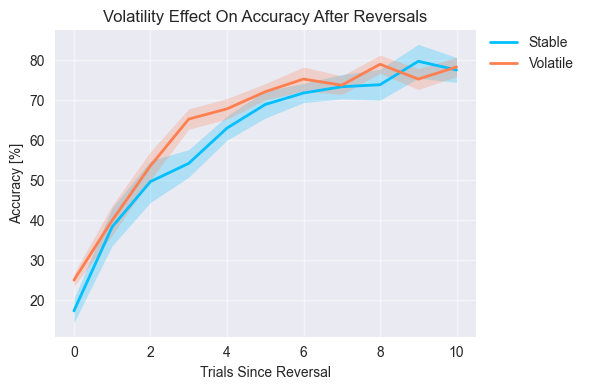

In [39]:
if dataset!='africa':
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened,
        x_col='trials_since_reversal_combined_learning', y_col='objectively_correct_boolean',
        xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
        subject_col='subject_id', condition_col='volatility',
        colours=['deepskyblue','coral'],
        output_dir=output_dir,
        legend_outside=True,
        plot_name='volatility effect on accuracy after reversals'
    );

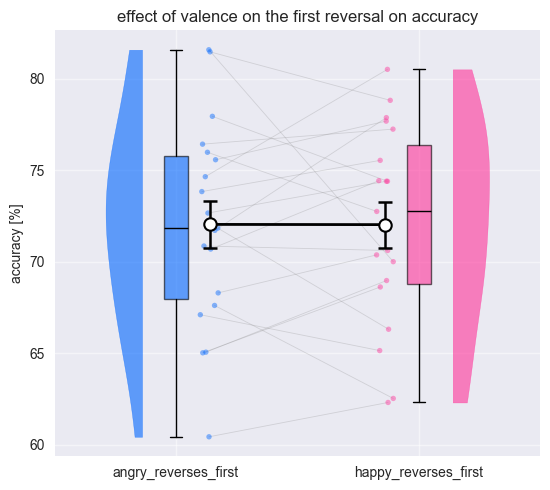

In [40]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns='valence_at_reversal',
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['angry_reverses_first','happy_reverses_first'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='effect of valence on the first reversal on accuracy'
    );

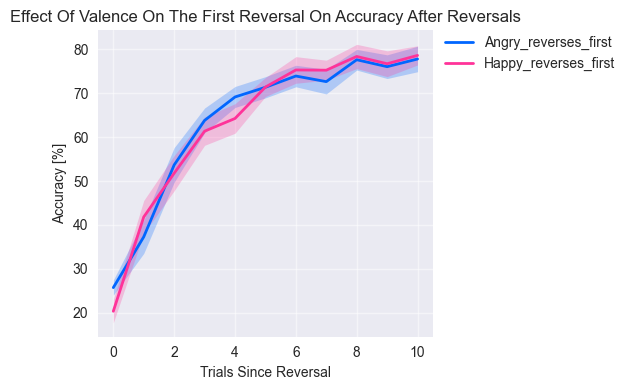

In [41]:
if dataset!='africa':
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened,
        x_col='trials_since_reversal_combined_learning', y_col='objectively_correct_boolean',
        xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
        subject_col='subject_id', condition_col='valence_at_reversal',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='effect of valence on the first reversal on accuracy after reversals'
    );

## Congruency split into response and valence

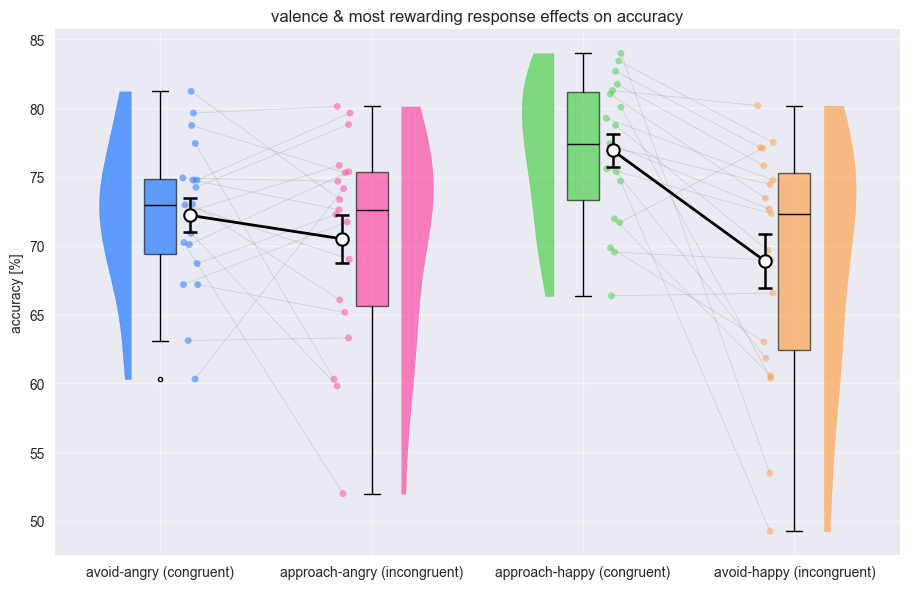

In [42]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns=['most_rewarding_response', 'valence'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    '_'.join(str(x) for x in col if x)
    for col in combined_results_pivoted.columns
]

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
    flip=['left','right','left','right'],
    connect_pairs=[(0, 1), (2, 3)],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='valence & most rewarding response effects on accuracy'
);

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/815296416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened['response_valence'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)


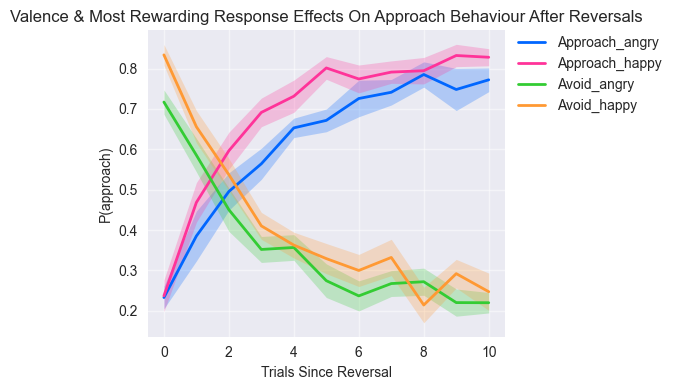

In [43]:
combined_results_dataframe_shortened['response_valence'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)

utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe_shortened,
    x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
    xlabel_name='trials since reversal', ylabel_name='p(approach)',
    subject_col='subject_id', condition_col='response_valence',
    output_dir=output_dir,
    legend_outside=True,
    plot_name='valence & most rewarding response effects on approach behaviour after reversals'
);

In [44]:
if dataset == 'africa':
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index='subject_id',
            columns=['most_rewarding_response', 'valence', 'stimulation_condition'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
    )
    combined_results_pivoted.columns = [f'{response}_{valence}_{condition}' for response, valence, condition in combined_results_pivoted.columns]
    combined_results_pivoted = combined_results_pivoted.reset_index()

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry_uwd','approach_angry_uwd','avoid_angry_control','approach_angry_control','approach_happy_uwd','avoid_happy_uwd','approach_happy_control','avoid_happy_control'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='uwd effect on valence & most rewarding response effects on accuracy'
    );

## Congruency split into valence and response, further split by volatility

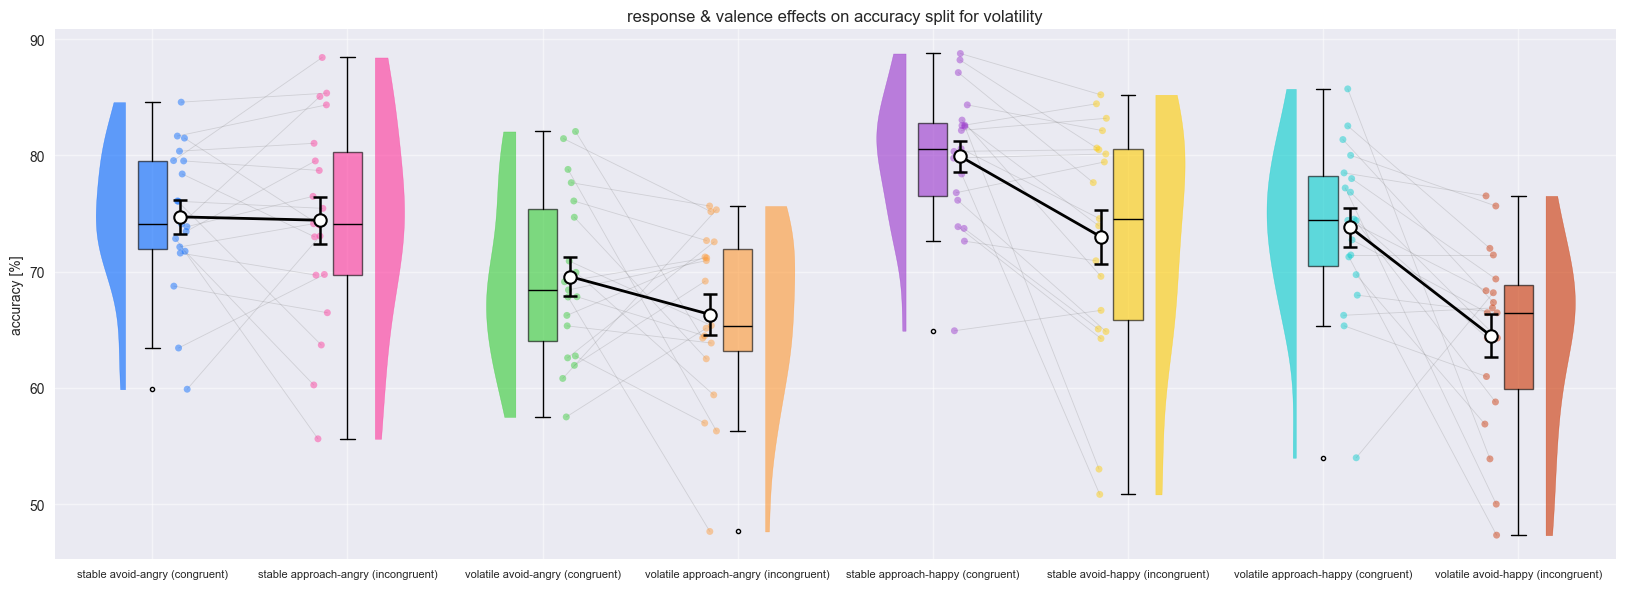

In [45]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='response & valence effects on accuracy split for volatility'
    );

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/4234328713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened['response_valence_volatility'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str) + '_' + combined_results_dataframe_shortened['volatility'].astype(str)


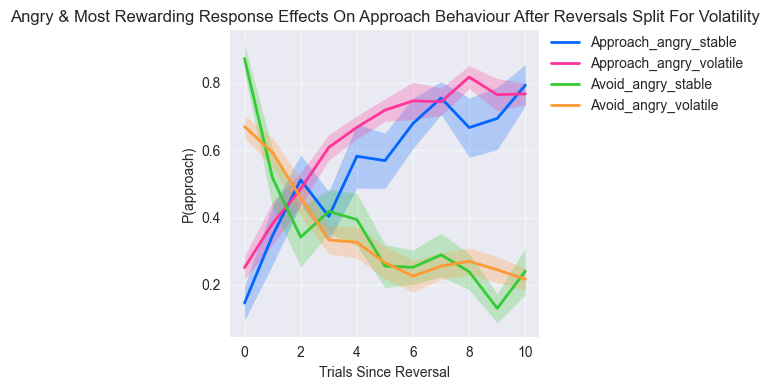

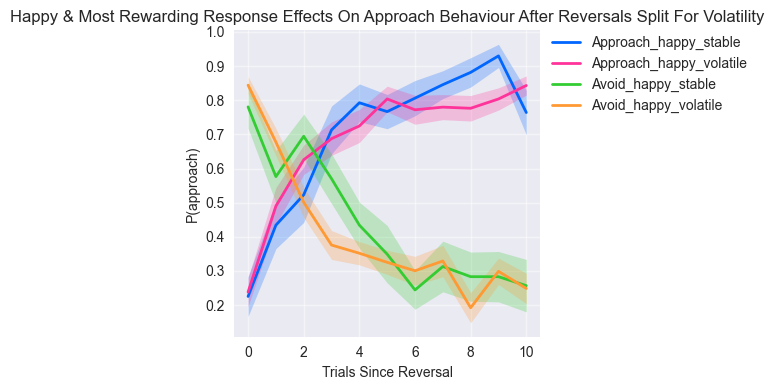

In [46]:
if dataset!='africa':
    combined_results_dataframe_shortened['response_valence_volatility'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str) + '_' + combined_results_dataframe_shortened['volatility'].astype(str)

    combined_results_dataframe_shortened_angry = combined_results_dataframe_shortened[combined_results_dataframe_shortened['response_valence_volatility'].isin([
        'approach_angry_stable',
        'approach_angry_volatile',
        'avoid_angry_stable',
        'avoid_angry_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_angry,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='angry & most rewarding response effects on approach behaviour after reversals split for volatility'
    );

    combined_results_dataframe_shortened_happy = combined_results_dataframe_shortened[combined_results_dataframe_shortened['response_valence_volatility'].isin([
        'approach_happy_stable',
        'approach_happy_volatile',
        'avoid_happy_stable',
        'avoid_happy_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_happy,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='happy & most rewarding response effects on approach behaviour after reversals split for volatility'
    );

response_valence_at_reversal
avoid_angry_reverses_first_happy       1410
approach_angry_reverses_first_angry    1342
approach_happy_reverses_first_happy    1316
avoid_happy_reverses_first_angry       1303
approach_angry_reverses_first_happy    1290
avoid_angry_reverses_first_angry       1284
approach_happy_reverses_first_angry    1218
avoid_happy_reverses_first_happy       1203
Name: count, dtype: int64


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/3751265422.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened['response_valence_at_reversal'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence_at_reversal'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)


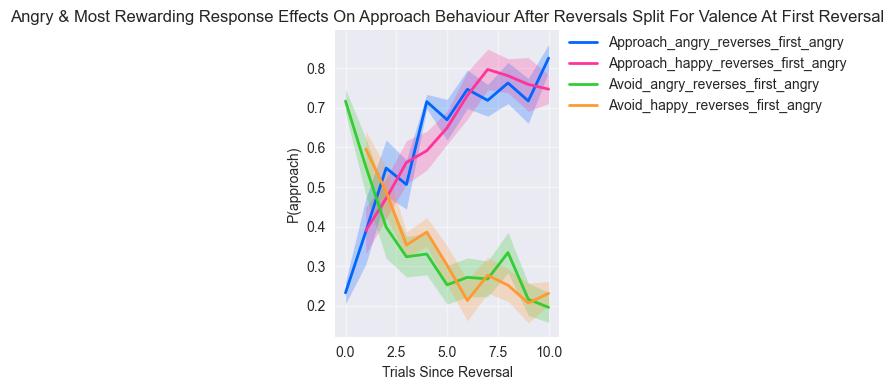

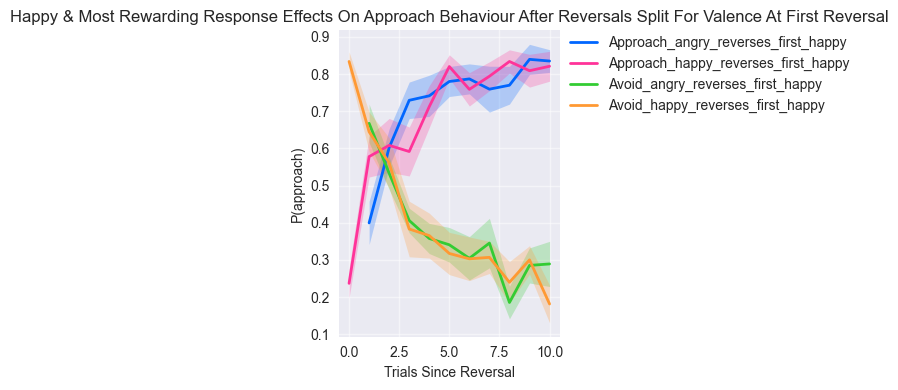

In [47]:
# improve this naming scheme

if dataset!='africa':
    combined_results_dataframe_shortened['response_valence_at_reversal'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence_at_reversal'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)
    print(combined_results_dataframe_shortened['response_valence_at_reversal'].value_counts())

    combined_results_dataframe_shortened_angry = combined_results_dataframe_shortened[combined_results_dataframe_shortened['response_valence_at_reversal'].isin([
        'approach_angry_reverses_first_angry',
        'approach_happy_reverses_first_angry',
        'avoid_angry_reverses_first_angry',
        'avoid_happy_reverses_first_angry'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_angry,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_at_reversal',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='angry & most rewarding response effects on approach behaviour after reversals split for valence at first reversal'
    );

    combined_results_dataframe_shortened_happy = combined_results_dataframe_shortened[combined_results_dataframe_shortened['response_valence_at_reversal'].isin([
        'approach_angry_reverses_first_happy',
        'approach_happy_reverses_first_happy',
        'avoid_angry_reverses_first_happy',
        'avoid_happy_reverses_first_happy'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_happy,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_at_reversal',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='happy & most rewarding response effects on approach behaviour after reversals split for valence at first reversal'
    );

# Check whether the effect holds over the whole experiment

In [48]:
combined_results_dataframe_session_2 = combined_results_dataframe[combined_results_dataframe['session']==2]
combined_results_dataframe_session_3 = combined_results_dataframe[combined_results_dataframe['session']==3]
combined_results_dataframe_session_4 = combined_results_dataframe[combined_results_dataframe['session']==4]
combined_results_dataframe_shortened_session_2 = combined_results_dataframe_shortened[combined_results_dataframe_shortened['session']==2]
combined_results_dataframe_shortened_session_3 = combined_results_dataframe_shortened[combined_results_dataframe_shortened['session']==3]
combined_results_dataframe_shortened_session_4 = combined_results_dataframe_shortened[combined_results_dataframe_shortened['session']==4]

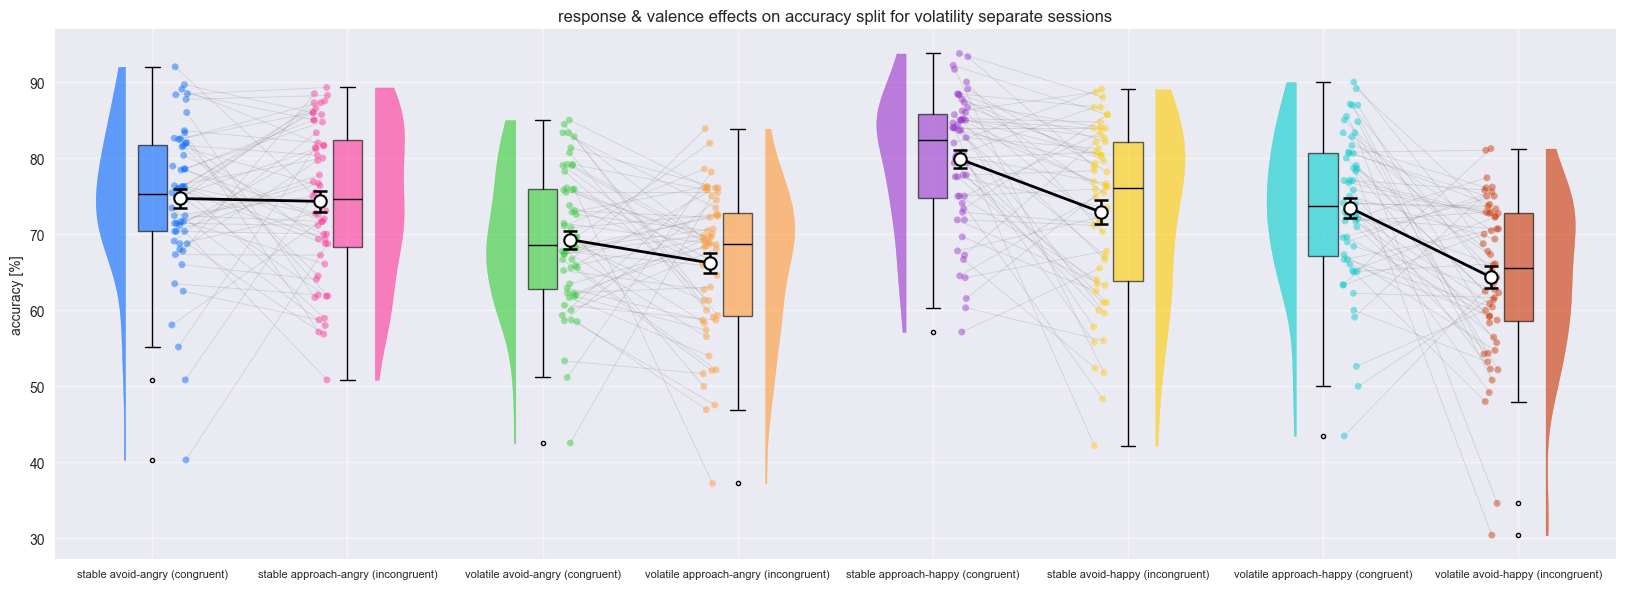

In [49]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id','session'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='response & valence effects on accuracy split for volatility separate sessions'
    );

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/1841843390.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened_session_2['response_valence_volatility'] = combined_results_dataframe_shortened_session_2['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_2['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_2['volatility'].astype(str)


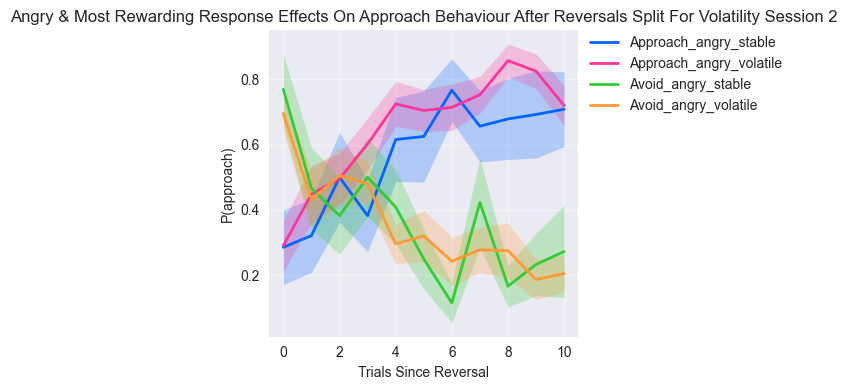

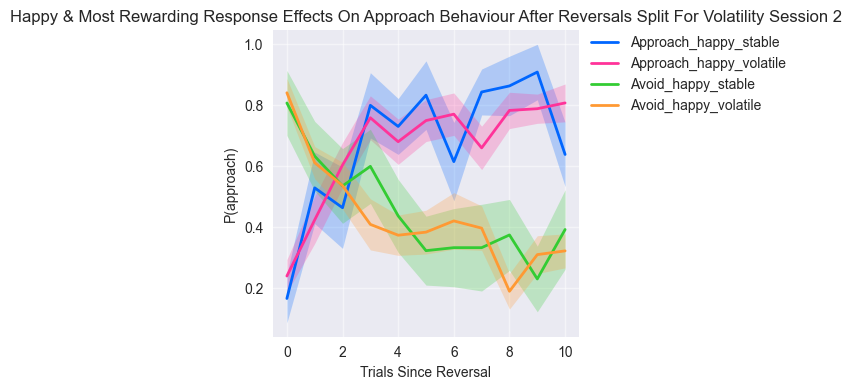

In [50]:
if dataset!='africa':
    combined_results_dataframe_shortened_session_2['response_valence_volatility'] = combined_results_dataframe_shortened_session_2['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_2['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_2['volatility'].astype(str)

    combined_results_dataframe_shortened_angry = combined_results_dataframe_shortened_session_2[combined_results_dataframe_shortened_session_2['response_valence_volatility'].isin([
        'approach_angry_stable',
        'approach_angry_volatile',
        'avoid_angry_stable',
        'avoid_angry_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_angry,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='angry & most rewarding response effects on approach behaviour after reversals split for volatility session 2'
    );

    combined_results_dataframe_shortened_happy = combined_results_dataframe_shortened_session_2[combined_results_dataframe_shortened_session_2['response_valence_volatility'].isin([
        'approach_happy_stable',
        'approach_happy_volatile',
        'avoid_happy_stable',
        'avoid_happy_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_happy,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='happy & most rewarding response effects on approach behaviour after reversals split for volatility session 2'
    );

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/2641052366.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened_session_3['response_valence_volatility'] = combined_results_dataframe_shortened_session_3['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_3['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_3['volatility'].astype(str)


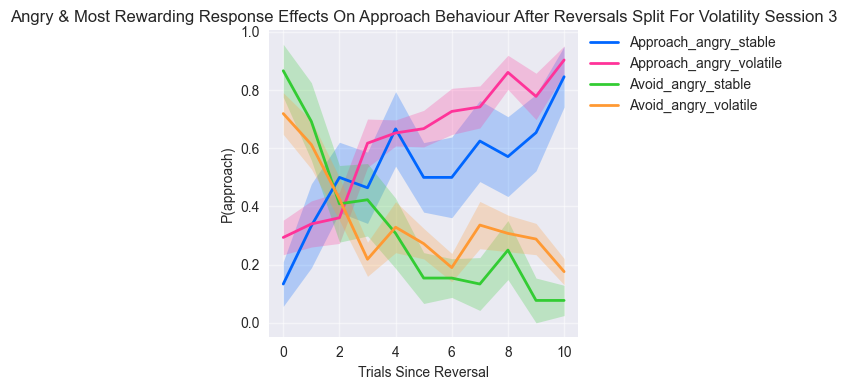

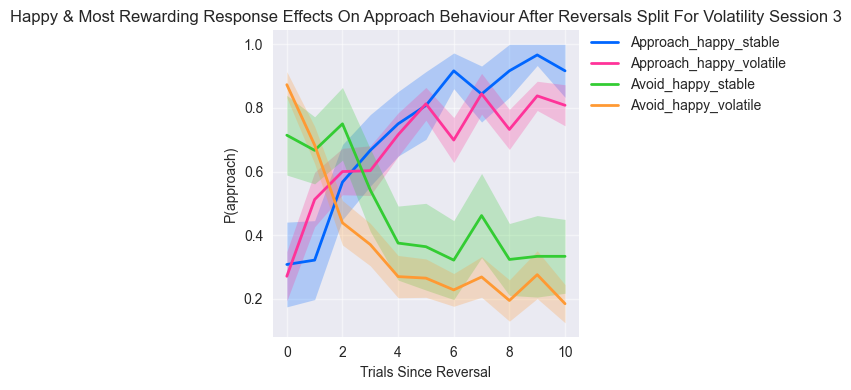

In [51]:
if dataset!='africa':
    combined_results_dataframe_shortened_session_3['response_valence_volatility'] = combined_results_dataframe_shortened_session_3['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_3['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_3['volatility'].astype(str)

    combined_results_dataframe_shortened_angry = combined_results_dataframe_shortened_session_3[combined_results_dataframe_shortened_session_3['response_valence_volatility'].isin([
        'approach_angry_stable',
        'approach_angry_volatile',
        'avoid_angry_stable',
        'avoid_angry_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_angry,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='angry & most rewarding response effects on approach behaviour after reversals split for volatility session 3'
    );

    combined_results_dataframe_shortened_happy = combined_results_dataframe_shortened_session_3[combined_results_dataframe_shortened_session_3['response_valence_volatility'].isin([
        'approach_happy_stable',
        'approach_happy_volatile',
        'avoid_happy_stable',
        'avoid_happy_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_happy,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='happy & most rewarding response effects on approach behaviour after reversals split for volatility session 3'
    );

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_7334/4103374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened_session_4['response_valence_volatility'] = combined_results_dataframe_shortened_session_4['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_4['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_4['volatility'].astype(str)


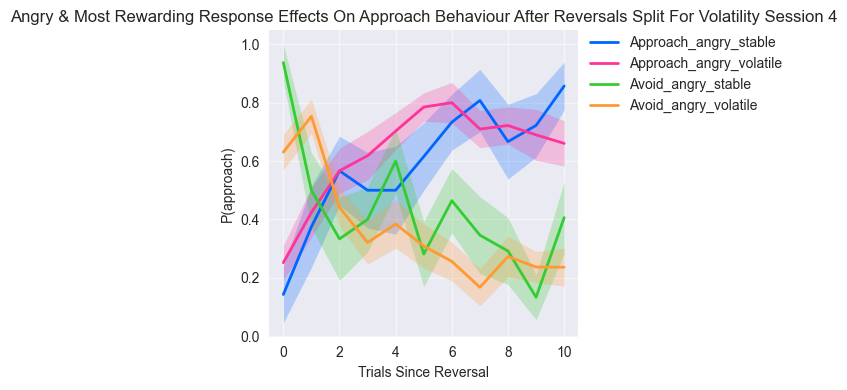

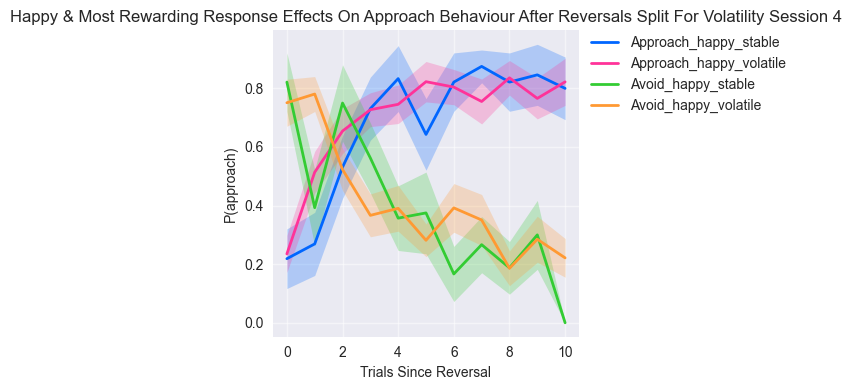

In [52]:
if dataset!='africa':
    combined_results_dataframe_shortened_session_4['response_valence_volatility'] = combined_results_dataframe_shortened_session_4['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened_session_4['valence'].astype(str) + '_' + combined_results_dataframe_shortened_session_4['volatility'].astype(str)

    combined_results_dataframe_shortened_angry = combined_results_dataframe_shortened_session_4[combined_results_dataframe_shortened_session_4['response_valence_volatility'].isin([
        'approach_angry_stable',
        'approach_angry_volatile',
        'avoid_angry_stable',
        'avoid_angry_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_angry,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='angry & most rewarding response effects on approach behaviour after reversals split for volatility session 4'
    );

    combined_results_dataframe_shortened_happy = combined_results_dataframe_shortened_session_4[combined_results_dataframe_shortened_session_4['response_valence_volatility'].isin([
        'approach_happy_stable',
        'approach_happy_volatile',
        'avoid_happy_stable',
        'avoid_happy_volatile'
    ])]
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened_happy,
        x_col='trials_since_reversal_combined_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='happy & most rewarding response effects on approach behaviour after reversals split for volatility session 4'
    );